<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Robust Portfolio Construction: Denoising, HRP &amp; NCO
    </h1>
  </div>  
</div>

Sample covariance matrices estimated from a finite history are dominated by
*estimation noise*: when the number of observations `T` is not much larger than
the number of assets `N`, the smallest eigenvalues are unreliable, and naive
mean–variance optimisation amplifies that noise into unstable, extreme weights.

This notebook walks the full RiskLabAI workflow for building a *robust*
portfolio:

1. simulate a known "true" market (block-structured covariance),
2. draw a noisy sample covariance from it,
3. **denoise** it with the Marčenko–Pastur method,
4. build portfolios with **Hierarchical Risk Parity (HRP)** and **Nested
   Clustered Optimisation (NCO)**, and
5. measure the realised (true) risk to show how denoising + hierarchical
   allocation beat naive Markowitz.

References: López de Prado, *Advances in Financial Machine Learning* (Ch. 2, 16)
and *Machine Learning for Asset Managers* (Ch. 2, 7).

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using RiskLabAI
using RiskLabAI.Data: form_true_matrix, simulates_cov_mu, cov_to_corr, denoise_cov
using Random, Statistics, LinearAlgebra
using Plots
gr()

  Activating project at `C:\arian\risklabai\Notebooks.jl`


Plots.GRBackend()

## 1. A known "true" market

`form_true_matrix` builds a shuffled block-diagonal correlation matrix (groups of
co-moving assets) and turns it into a covariance matrix with random volatilities,
plus a true mean vector. Because *we* generate it, we know the ground truth
`Σ₀` and can later measure how much risk each portfolio *actually* takes.

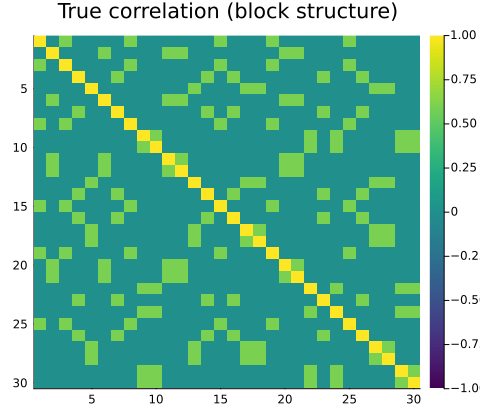

In [2]:
rng = MersenneTwister(42)
n_blocks, block_size, block_corr = 5, 6, 0.6      # 30 assets in 5 correlated blocks

mu0, cov0 = form_true_matrix(n_blocks, block_size, block_corr; rng = rng)
n_assets = size(cov0, 1)
corr0 = cov_to_corr(cov0)

heatmap(corr0; title = "True correlation (block structure)", c = :viridis,
        clims = (-1, 1), yflip = true, size = (480, 420))

## 2. The noisy sample we actually observe

In practice we never see `Σ₀`; we estimate it from `T` return observations.
With `T` only modestly larger than `N`, the sample correlation is visibly
blurred by estimation noise.

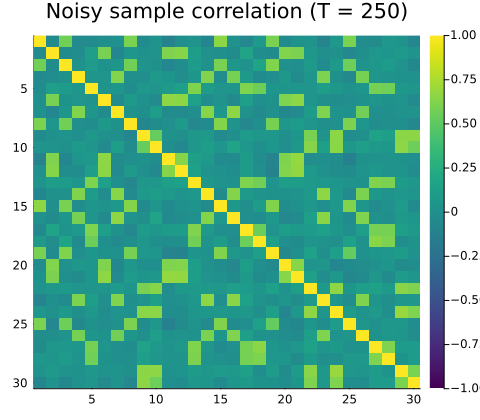

In [3]:
n_obs = 250                                       # T observations (T / N ≈ 8.3)
mu1, cov1 = simulates_cov_mu(mu0, cov0, n_obs; rng = rng)
corr1 = cov_to_corr(cov1)

heatmap(corr1; title = "Noisy sample correlation (T = $(n_obs))", c = :viridis,
        clims = (-1, 1), yflip = true, size = (480, 420))

## 3. Denoising with Marčenko–Pastur

Random-matrix theory tells us which eigenvalues are consistent with pure noise
(they fall inside the Marčenko–Pastur band, set by the ratio `q = T / N`).
`denoise_cov` shrinks those noise eigenvalues to their average, keeping the
signal eigenvalues intact — recovering a cleaner correlation structure.

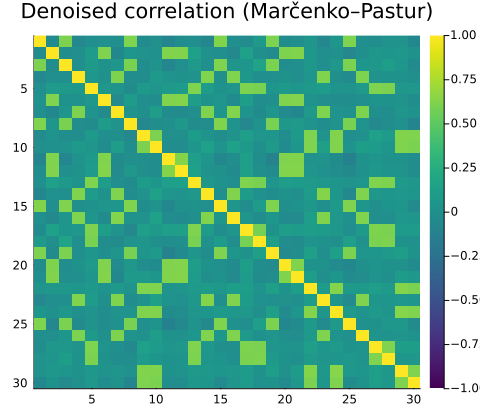

In [4]:
q = n_obs / n_assets
cov1_denoised = denoise_cov(cov1, q)
corr1_denoised = cov_to_corr(cov1_denoised)

heatmap(corr1_denoised; title = "Denoised correlation (Marčenko–Pastur)",
        c = :viridis, clims = (-1, 1), yflip = true, size = (480, 420))

## 4. Four ways to build a portfolio

- **Inverse-variance (IVP)** — weight each asset by `1/σ²`; ignores correlations.
- **Markowitz GMV** — the global-minimum-variance solution `Σ⁻¹𝟙`; mathematically
  optimal but notoriously unstable when `Σ` is noisy.
- **HRP** — clusters assets by a correlation distance and allocates by recursive
  bisection; never inverts the full covariance.
- **NCO** — clusters assets, optimises *within* each cluster and *between*
  clusters, then recombines.

We build all four on both the **raw** and the **denoised** covariance.

In [5]:
inverse_variance(c) = (w = 1.0 ./ diag(c); w ./ sum(w))

function build_portfolios(cov, corr)
    return (
        IVP = inverse_variance(cov),
        Markowitz = get_optimal_portfolio_weights(cov),
        HRP = hrp(cov, corr),
        NCO = vec(get_optimal_portfolio_weights_nco(cov; number_clusters = n_blocks)),
    )
end

build_portfolios (generic function with 1 method)

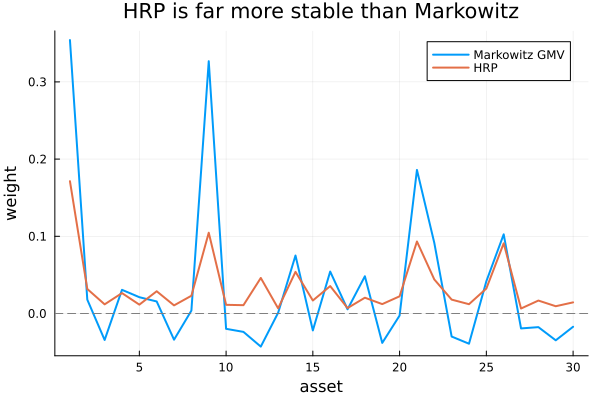

In [6]:
raw = build_portfolios(cov1, corr1)
den = build_portfolios(cov1_denoised, corr1_denoised)

# HRP vs Markowitz weights on the raw covariance — note Markowitz's extreme bets.
plot(1:n_assets, raw.Markowitz; label = "Markowitz GMV", lw = 2,
     xlabel = "asset", ylabel = "weight", title = "HRP is far more stable than Markowitz")
plot!(1:n_assets, raw.HRP; label = "HRP", lw = 2)
hline!([0.0]; label = "", c = :gray, ls = :dash)

## 5. Which portfolio actually takes less risk?

Because we know the true covariance `Σ₀`, the realised out-of-sample variance of
any weight vector `w` is `wᵀ Σ₀ w`. A robust method should deliver *lower* true
risk, and denoising should help every method.

IVP        raw = 0.0012   denoised = 0.0012
Markowitz  raw = 0.00067   denoised = 0.00062
HRP        raw = 0.00121   denoised = 0.00118
NCO        raw = 0.00062   denoised = 0.00061


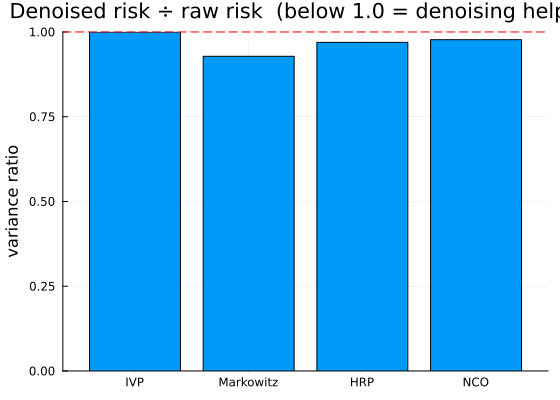

In [7]:
true_variance(w) = (w' * cov0 * w)
methods = ["IVP", "Markowitz", "HRP", "NCO"]

raw_var = [true_variance(getfield(raw, Symbol(m))) for m in methods]
den_var = [true_variance(getfield(den, Symbol(m))) for m in methods]

for (m, r, d) in zip(methods, raw_var, den_var)
    println(rpad(m, 11), "raw = ", round(r; digits = 5), "   denoised = ", round(d; digits = 5))
end

bar(methods, den_var ./ raw_var;
    title = "Denoised risk ÷ raw risk  (below 1.0 = denoising helped)",
    ylabel = "variance ratio", legend = false, size = (560, 400))
hline!([1.0]; c = :red, ls = :dash)

## Takeaways

- The sample covariance is badly blurred by estimation noise; Marčenko–Pastur
  denoising recovers the block structure.
- **Markowitz GMV** places large, often negative bets and carries high realised
  risk — it trusts the noisy covariance too much.
- **HRP** and **NCO** spread risk across clusters and are far more stable.
- Denoising lowers the realised variance of essentially every method.

Every function used here — `form_true_matrix`, `simulates_cov_mu`, `denoise_cov`,
`get_optimal_portfolio_weights`, `hrp`, `get_optimal_portfolio_weights_nco` —
comes straight from `RiskLabAI.jl`.